In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("Churn_Modelling.csv")
df.sample(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
5814,5815,15725882,Feng,618,Germany,Female,40,1,133245.52,2,1,1,54495.82,0
1158,1159,15690007,Ts'ui,434,Germany,Female,58,9,125801.03,2,1,0,60891.80,1
9744,9745,15785358,Gresswell,586,Germany,Male,46,8,106968.96,1,1,1,79366.98,1
2729,2730,15608230,Hoelscher,667,France,Male,23,1,0.00,2,1,0,91573.19,0
9700,9701,15797149,Lloyd,563,Spain,Female,36,4,143680.47,2,1,1,63531.19,0
8409,8410,15590011,Hughes,749,Spain,Male,38,9,129378.32,1,1,1,13549.34,0
3272,3273,15793890,Harriman,728,France,Female,59,4,0.00,1,1,1,163365.85,1
7719,7720,15775433,Tang,666,Germany,Male,71,1,53013.29,2,1,1,112222.64,0
3280,3281,15715622,To Rot,583,France,Female,57,3,238387.56,1,0,1,147964.99,1
2384,2385,15758531,Y?,732,France,Female,40,10,0.00,2,1,0,154189.08,0


In [3]:
df=df.drop(["RowNumber","CustomerId","Surname"],axis=1)

In [4]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [5]:
df=pd.get_dummies(df,["Geography","Gender"],drop_first=True)

In [6]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 

In [8]:
X_train,X_test,y_train,y_test=train_test_split(df.drop("Exited",axis=1),df["Exited"],test_size=0.2,random_state=42,stratify=df["Exited"])

In [9]:
sc=StandardScaler()

In [10]:
X_train_scl=sc.fit_transform(X_train)
X_test_scl=sc.transform(X_test)

In [11]:
import tensorflow as tf


In [12]:
model=tf.keras.Sequential()

model.add(tf.keras.layers.Dense(3,activation="sigmoid",input_dim=11))
model.add(tf.keras.layers.Dense(1,activation="sigmoid"))

c:\Users\sm\AppData\Local\anaconda3\envs\dnn\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 40 (160.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(loss="binary_crossentropy",optimizer="Adam",metrics=["accuracy"])

In [15]:
history=model.fit(X_train_scl,y_train,epochs=20,validation_split=0.2)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2659 - loss: 0.7951 - val_accuracy: 0.4812 - val_loss: 0.7069
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6967 - loss: 0.6432 - val_accuracy: 0.8106 - val_loss: 0.5909
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7973 - loss: 0.5563 - val_accuracy: 0.8000 - val_loss: 0.5270
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7953 - loss: 0.5092 - val_accuracy: 0.8000 - val_loss: 0.4926
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7953 - loss: 0.4838 - val_accuracy: 0.8000 - val_loss: 0.4732
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7953 - loss: 0.4687 - val_accuracy: 0.8000 - val_loss: 0.4612
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7953 - loss: 0.4585 - val_accuracy: 0.8000 - val_loss: 0.4527
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7953 - loss: 0.4509 - val_accuracy: 0.

In [16]:
model.layers[0].get_weights()

[array([[-0.04531236,  0.04989703,  0.23372361],
        [ 0.89757526, -0.96323305, -3.034006  ],
        [-0.08909808, -0.03239294,  0.02990514],
        [ 0.36996514, -0.38369372, -0.21390685],
        [-0.20075855,  0.15479915,  0.1459428 ],
        [-0.09596005, -0.17933404, -0.00994521],
        [-1.2777934 ,  0.9151441 ,  0.3239425 ],
        [ 0.23982506, -0.19795683,  0.13169956],
        [ 0.63340545, -0.9123168 , -0.59280455],
        [-0.13953258, -0.11300386, -0.12804002],
        [-0.6406351 ,  0.727585  ,  0.35535553]], dtype=float32),
 array([-0.5906922 ,  0.11286341,  0.77678156], dtype=float32)]

In [17]:
model.layers[1].get_weights()

[array([[ 0.9032788 ],
        [-0.76069283],
        [-1.4990001 ]], dtype=float32),
 array([-0.6547813], dtype=float32)]

In [18]:
y_pred_proba=model.predict(X_test_scl)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [19]:
y_pred=np.where(y_pred_proba>0.5,1,0)

In [20]:
from sklearn.metrics import accuracy_score

In [21]:
accuracy_score(y_test,y_pred)

0.8195

In [24]:
history.history

{'accuracy': [0.2659375071525574,
  0.6967187523841858,
  0.7973437309265137,
  0.7953125238418579,
  0.7953125238418579,
  0.7953125238418579,
  0.7953125238418579,
  0.7953125238418579,
  0.7953125238418579,
  0.7953125238418579,
  0.7953125238418579,
  0.7953125238418579,
  0.7953125238418579,
  0.7953125238418579,
  0.801562488079071,
  0.8106250166893005,
  0.8121874928474426,
  0.8139062523841858,
  0.817187488079071,
  0.8181250095367432],
 'loss': [0.7951210737228394,
  0.6431825757026672,
  0.5563205480575562,
  0.5091604590415955,
  0.48376479744911194,
  0.468729704618454,
  0.4584982693195343,
  0.450903058052063,
  0.44491976499557495,
  0.44004812836647034,
  0.4360441565513611,
  0.43276435136795044,
  0.43014591932296753,
  0.4279906153678894,
  0.42623353004455566,
  0.4248501658439636,
  0.42364421486854553,
  0.42255863547325134,
  0.4215953052043915,
  0.42071980237960815],
 'val_accuracy': [0.48124998807907104,
  0.8106250166893005,
  0.800000011920929,
  0.8000000

In [27]:
import matplotlib.pyplot as plt

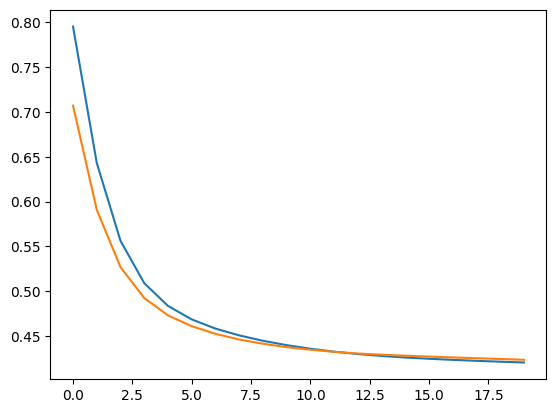

In [28]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

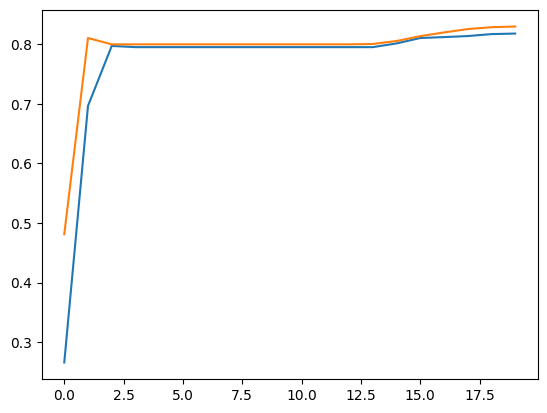

In [29]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])